# I. Analyse SARIMAX de la Production Nationale avec Variables Exogènes

Ce notebook présente le pipeline complet pour :
- Charger et préparer les données agrégées au niveau national.
- Séparer les données en périodes d'entraînement et de test.
- Ajuster un modèle SARIMAX intégrant les variables climatiques et économiques comme exogènes.
- Réaliser des prévisions et évaluer les performances du modèle.

La liste des variables clés utilisée est la suivante :
```python
key_vars = ['Production', 'Temperature', 'Precipitation', 'Cloud_Cover', 'Diurnal_Temp_Range', 
            'Frost_Days', 'Potential_Evapotranspiration', 'Anomalie_Cloud_Cover',
            'Anomalie_Diurnal_Temp_Range', 'Anomalie_Frost_Days', 
            'Anomalie_Potential_Evapotranspiration', 'Anomalie_Precipitation', 'Anomalie_Temperature',
            'Temp_Min', 'Temp_Max', 'Vapor_Pressure', 'Wet_Days', 'Anomalie_Vapor_Pressure',
            'Anomalie_Wet_Days', 'prix_lme', 'export_tot']


In [1]:
# Import des librairies nécessaires pour la manipulation, la visualisation, l'analyse des séries temporelles et l'évaluation du modèle.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Chargement et Préparation des Données

Nous chargeons le fichier CSV nettoyé et normalisé, convertissons la colonne `Date` en type datetime, et la définissons comme index pour faciliter l'analyse chronologique.

In [2]:
# Lecture du fichier CSV contenant les données nettoyées et normalisées.
df_panel = pd.read_csv(r"C:\Users\march\OneDrive\Bureau\Data_Science\Dossier\03.code\final_merged_data_normalized.csv", sep=",")

# Conversion de la colonne 'Date' en datetime et définition comme index
df_panel['Date'] = pd.to_datetime(df_panel['Date'])
df_panel.set_index('Date', inplace=True)
df_panel = df_panel.sort_index()

# Affichage d'un aperçu des données
print("Aperçu des données (panel) :")
print(df_panel.head())


Aperçu des données (panel) :
                       Mine  Production   Latitude  Longitude  Cloud_Cover  \
Date                                                                         
2003-01-01           Andina   19.799999 -33.150873 -70.261021    24.800001   
2003-01-01         Salvador    5.700000 -26.282693 -69.597913    47.799999   
2003-01-01       Collahuasi   35.799999 -20.982384 -68.632167    74.599998   
2003-01-01  Quebrada Blanca    6.300000 -21.004622 -68.799554    74.599998   
2003-01-01          El Abra   17.500000 -21.925813 -68.829683    71.700005   

            Diurnal_Temp_Range    Frost_Days  Potential_Evapotranspiration  \
Date                                                                         
2003-01-01           11.200000  6.177600e+14                           4.4   
2003-01-01            8.200000  0.000000e+00                           4.4   
2003-01-01           10.100000  8.873280e+14                           3.1   
2003-01-01            9.800000  7.

## 2. Agrégation Nationale

Pour obtenir une vue nationale :
- La **Production** est agrégée par somme (total national).
- Les autres variables (climatiques, économiques) sont agrégées par moyenne.


In [24]:
# Définition de la liste des variables clés
key_vars = ['Production', 'Temperature', 'Precipitation', 'Cloud_Cover', 'Diurnal_Temp_Range', 
            'Frost_Days', 'Potential_Evapotranspiration', 'Anomalie_Cloud_Cover',
            'Anomalie_Diurnal_Temp_Range', 'Anomalie_Frost_Days', 
            'Anomalie_Potential_Evapotranspiration', 'Anomalie_Precipitation', 'Anomalie_Temperature',
            'Temp_Min', 'Temp_Max', 'Vapor_Pressure', 'Wet_Days', 'Anomalie_Vapor_Pressure',
            'Anomalie_Wet_Days', 'prix_lme', 'export_tot']

# Création du dictionnaire d'agrégation : somme pour Production, moyenne pour les autres
agg_dict = {var: ('sum' if var == 'Production' else 'mean') for var in key_vars}

# Agrégation par date
df_national = df_panel.groupby('Date').agg(agg_dict).reset_index()
df_national['Date'] = pd.to_datetime(df_national['Date'])
df_national.set_index('Date', inplace=True)
df_national = df_national.sort_index()

# Affichage d'un aperçu des données agrégées
print("Aperçu des données nationales agrégées :")
print(df_national.head())


Aperçu des données nationales agrégées :
            Production  Temperature  Precipitation  Cloud_Cover  \
Date                                                              
2003-01-01  239.899999    13.907693      14.746154    57.407693   
2003-02-01  222.399999    14.069231       5.669231    48.346155   
2003-03-01  245.600001    12.861539       2.792308    48.107693   
2003-04-01  223.700001    10.553846       0.692308    42.176923   
2003-05-01  247.000000     8.730769      15.592308    42.107693   

            Diurnal_Temp_Range    Frost_Days  Potential_Evapotranspiration  \
Date                                                                         
2003-01-01            8.807692  2.088886e+14                      3.900000   
2003-02-01           10.876923  2.197218e+14                      4.015385   
2003-03-01            9.700000  3.080492e+14                      3.346154   
2003-04-01           10.415385  5.793452e+14                      2.876923   
2003-05-01           

## 3. Définition de la Série Cible et des Variables Exogènes

La série temporelle cible est la **Production** agrégée.  
Les variables exogènes sont toutes les variables de `key_vars` sauf **Production**.


In [25]:
# Série cible : Production agrégée nationale
production_national = df_national['Production']

# Définition des variables exogènes (toutes les variables sauf 'Production')
exog_vars = [var for var in key_vars if var != 'Production']
exog_national = df_national[exog_vars]


## 4. Analyse ACF/PACF de la Série de Production

L'analyse des fonctions d'autocorrélation (ACF) et d'autocorrélation partielle (PACF) permet d'identifier les ordres potentiels des composantes AR et MA ainsi que la nécessité de différenciation pour rendre la série stationnaire.


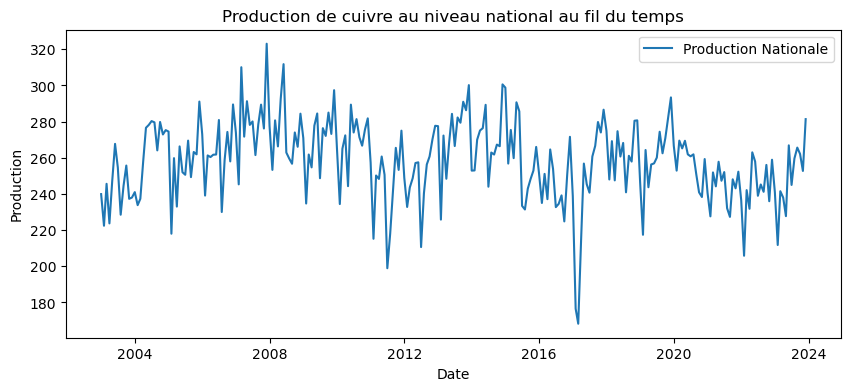

In [26]:
# Affichage de la série temporelle
plt.figure(figsize=(10,4))
plt.plot(production_national, label="Production Nationale")
plt.title("Production de cuivre au niveau national au fil du temps")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [27]:
# Calcul de l'ACF et de la PACF pour la série de production nationale
lag_acf = acf(production_national, nlags=24)
lag_pacf = pacf(production_national, nlags=24)

print("ACF premiers décalages :", np.round(lag_acf[:5], 3))
print("PACF premiers décalages :", np.round(lag_pacf[:5], 3))

ACF premiers décalages : [1.    0.467 0.31  0.248 0.195]
PACF premiers décalages : [1.    0.469 0.119 0.086 0.041]


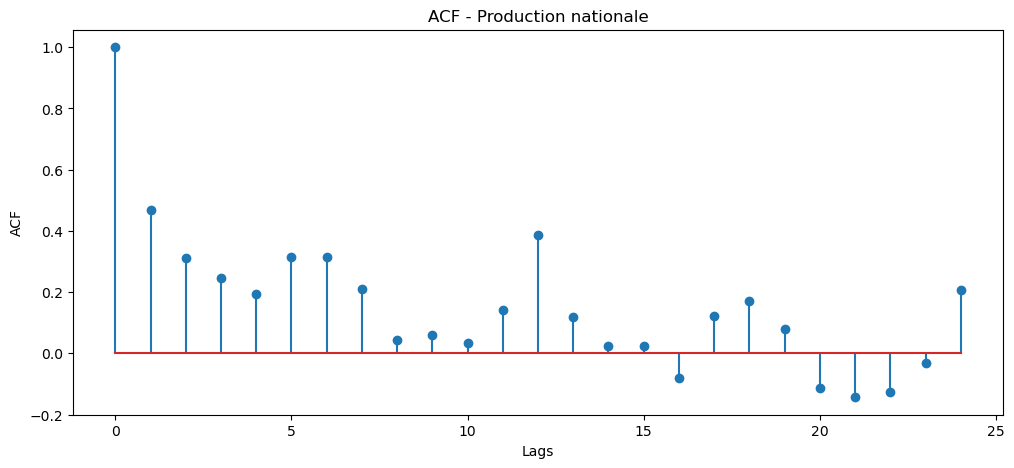

In [28]:
# Visualisation de l'ACF
plt.figure(figsize=(12, 5))
plt.stem(range(len(lag_acf)), lag_acf)
plt.title("ACF - Production nationale")
plt.xlabel("Lags")
plt.ylabel("ACF")
plt.show()

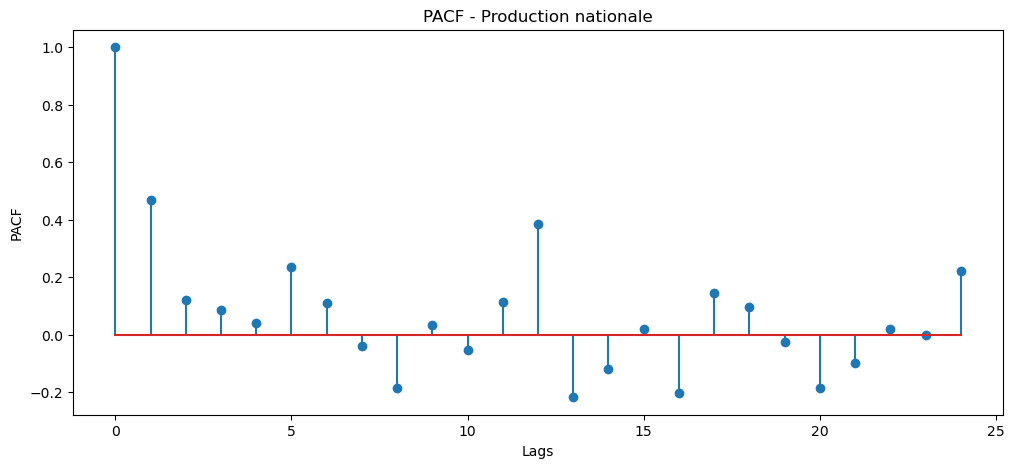

In [29]:
# Visualisation de la PACF
plt.figure(figsize=(12, 5))
plt.stem(range(len(lag_pacf)), lag_pacf)
plt.title("PACF - Production nationale")
plt.xlabel("Lags")
plt.ylabel("PACF")
plt.show()

Les graphiques ACF/PACF indiquent qu’il faut probablement différencier la série (d=1) et qu’il existe une composante AR(1) et MA(1) non négligeable, ainsi qu’une saisonnalité à 12 mois qui pourrait requérir (P=1, D=1, Q=1). C’est pourquoi un modèle SARIMA(1,1,1)(1,1,1,12) constitue un bon candidat initial.

## 5. Séparation en Jeux d'Entraînement et de Test

Nous utilisons les données jusqu'à 2022 pour entraîner le modèle et celles de l'année 2023 pour tester ses performances.


In [30]:
# Séparation temporelle des données : entraînement (jusqu'à 2022) et test (2023)
train = df_national[:'2022']
test = df_national['2023':]

# Extraction de la production et des exogènes pour l'entraînement et le test
train_production = train['Production']
test_production = test['Production']
train_exog = train[exog_vars]
test_exog = test[exog_vars]


## 6. Ajustement du Modèle SARIMAX

Nous ajustons un modèle SARIMAX sur la série d'entraînement en intégrant les variables exogènes.  
Les paramètres choisis ici sont (1,1,1) pour la partie ARIMA et (1,1,1,12) pour la composante saisonnière.  


In [31]:
# Ajustement du modèle SARIMAX sur la production nationale avec les variables exogènes

df_national = df_national.asfreq('MS')  # ou 'M' selon votre cas
model = SARIMAX(train_production, 
                order=(1,1,1), 
                seasonal_order=(1,1,1,12),
                exog=train_exog, 
                enforce_stationarity=False, 
                enforce_invertibility=False)

# Fit du modèle
result = model.fit(disp=False)
print(result.summary())

C:\Users\march\anaconda3\envs\python_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\march\anaconda3\envs\python_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\march\anaconda3\envs\python_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                        SARIMAX Results                                        
Dep. Variable:                         Production   No. Observations:                       240
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood      -837618585468543488.000
Date:                            Mon, 10 Mar 2025   AIC                 1675237170937086976.000
Time:                                    04:45:54   BIC                 1675237170937087232.000
Sample:                                01-01-2003   HQIC                1675237170937086976.000
                                     - 12-01-2022                                              
Covariance Type:                              opg                                              
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Temperature         

les résultats montrent que :
- AR non saisonnier (ar.L1 ≈ 0.10) et MA non saisonnier (ma.L1 ≈ -0.50) indiquent une influence des valeurs passées immédiates.
- Composantes saisonnières (ar.S.L12 ≈ -0.36, ma.S.L12 ≈ -0.24) soulignent une saisonnalité annuelle sur données mensuelles.
- Tous les coefficients des variables exogènes sont statistiquement significatifs (p < 0.001), ce qui montre qu'elles influencent la production.
- Toutefois, la redondance (coefficients identiques pour certaines variables similaires) suggère une forte colinéarité.

## 7. Prévision et Évaluation du Modèle

Nous réalisons des prévisions pour l'année 2023 en utilisant les variables exogènes correspondantes.  
Ensuite, nous évaluons les performances du modèle à l'aide des indicateurs MAE et RMSE, et visualisons les résultats.


In [32]:
# Prévision hors-échantillon pour la période de test (2023)
n_steps = len(test_production)
forecast = result.get_forecast(steps=n_steps, exog=test_exog)
pred_mean = forecast.predicted_mean
pred_mean.index = test_production.index  # Alignement des index

In [34]:
!pip install --upgrade scikit-learn --quiet

In [36]:
# Calcul des erreurs : MAE et RMSE
mae = mean_absolute_error(test_production, pred_mean)
mse = mean_squared_error(test_production, pred_mean)  # MSE par défaut
rmse = mse ** 0.5                                     # Conversion en RMSE
print(f"Performance SARIMAX (niveau national) sur 2023 – MAE: {mae:.2f}, RMSE: {rmse:.2f}")


Performance SARIMAX (niveau national) sur 2023 – MAE: 17.73, RMSE: 21.47


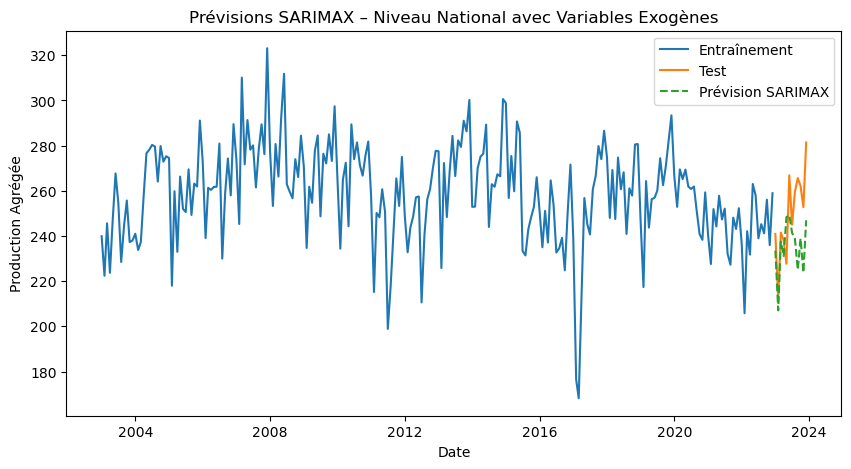

In [37]:
# Visualisation : comparaison entre la série d'entraînement, de test et les prévisions
plt.figure(figsize=(10, 5))
plt.plot(train_production.index, train_production, label='Entraînement')
plt.plot(test_production.index, test_production, label='Test')
plt.plot(pred_mean.index, pred_mean, label='Prévision SARIMAX', linestyle='--')
plt.legend()
plt.title("Prévisions SARIMAX – Niveau National avec Variables Exogènes")
plt.xlabel("Date")
plt.ylabel("Production Agrégée")
plt.show()

In [38]:
# Tableau comparatif des premières valeurs réelles et prévues
comparison = pd.DataFrame({"Réel": test_production, "Prévision": pred_mean})
print("Comparaison réelles vs prévisions (quelques points) :")
print(comparison.head())

Comparaison réelles vs prévisions (quelques points) :
                  Réel   Prévision
Date                              
2023-01-01  240.914000  233.578125
2023-02-01  211.751005  207.093750
2023-03-01  241.516000  237.562500
2023-04-01  237.991998  231.156250
2023-05-01  227.714373  248.375000


Les prévisions du modèle sont globalement proches des valeurs réelles (ex. janvier : réel 240.91 vs prévision 233.58).

Les résultats montrent que le modèle SARIMAX capture globalement la dynamique de la production nationale en intégrant une saisonnalité mensuelle et l’impact des variables exogènes. Toutefois, les problèmes de convergence et de colinéarité des exogènes limitent la fiabilité des estimations. Une simplification du modèle et une réduction des variables redondantes pourraient améliorer les performances et la robustesse des prévisions.